# Prediksi Kelulusan Mahasiswa Menggunakan Algoritma SVM
**Dataset:** Predict Students' Dropout and Academic Success (UCI)  
**Link:** https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success  
**Mata Kuliah:** Machine Learning  
**Program Studi:** Sistem Informasi — Fakultas Telemtika Energi, IT PLN  

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split as tts
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv("Predict Students' Dropout and Academic Success.csv", sep=';')
# df.columns = df.columns.str.strip()
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [3]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
print('Jumlah data  :', df.shape[0])
print('Jumlah kolom :', df.shape[1])
print()
print('Distribusi kelas Target:')
print(df['Target'].value_counts())

Jumlah data  : 4424
Jumlah kolom : 37

Distribusi kelas Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


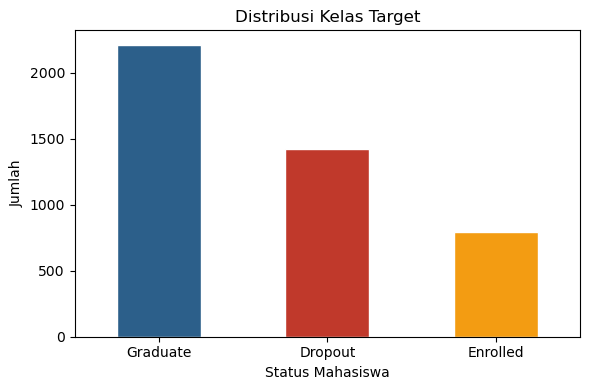

In [7]:
# Distribusi kelas Target
plt.figure(figsize=(6, 4))
df['Target'].value_counts().plot(kind='bar', color=['#2C5F8A','#C0392B','#F39C12'], edgecolor='white')
plt.title('Distribusi Kelas Target')
plt.xlabel('Status Mahasiswa')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Heatmap Korelasi Fitur terhadap Kelulusan

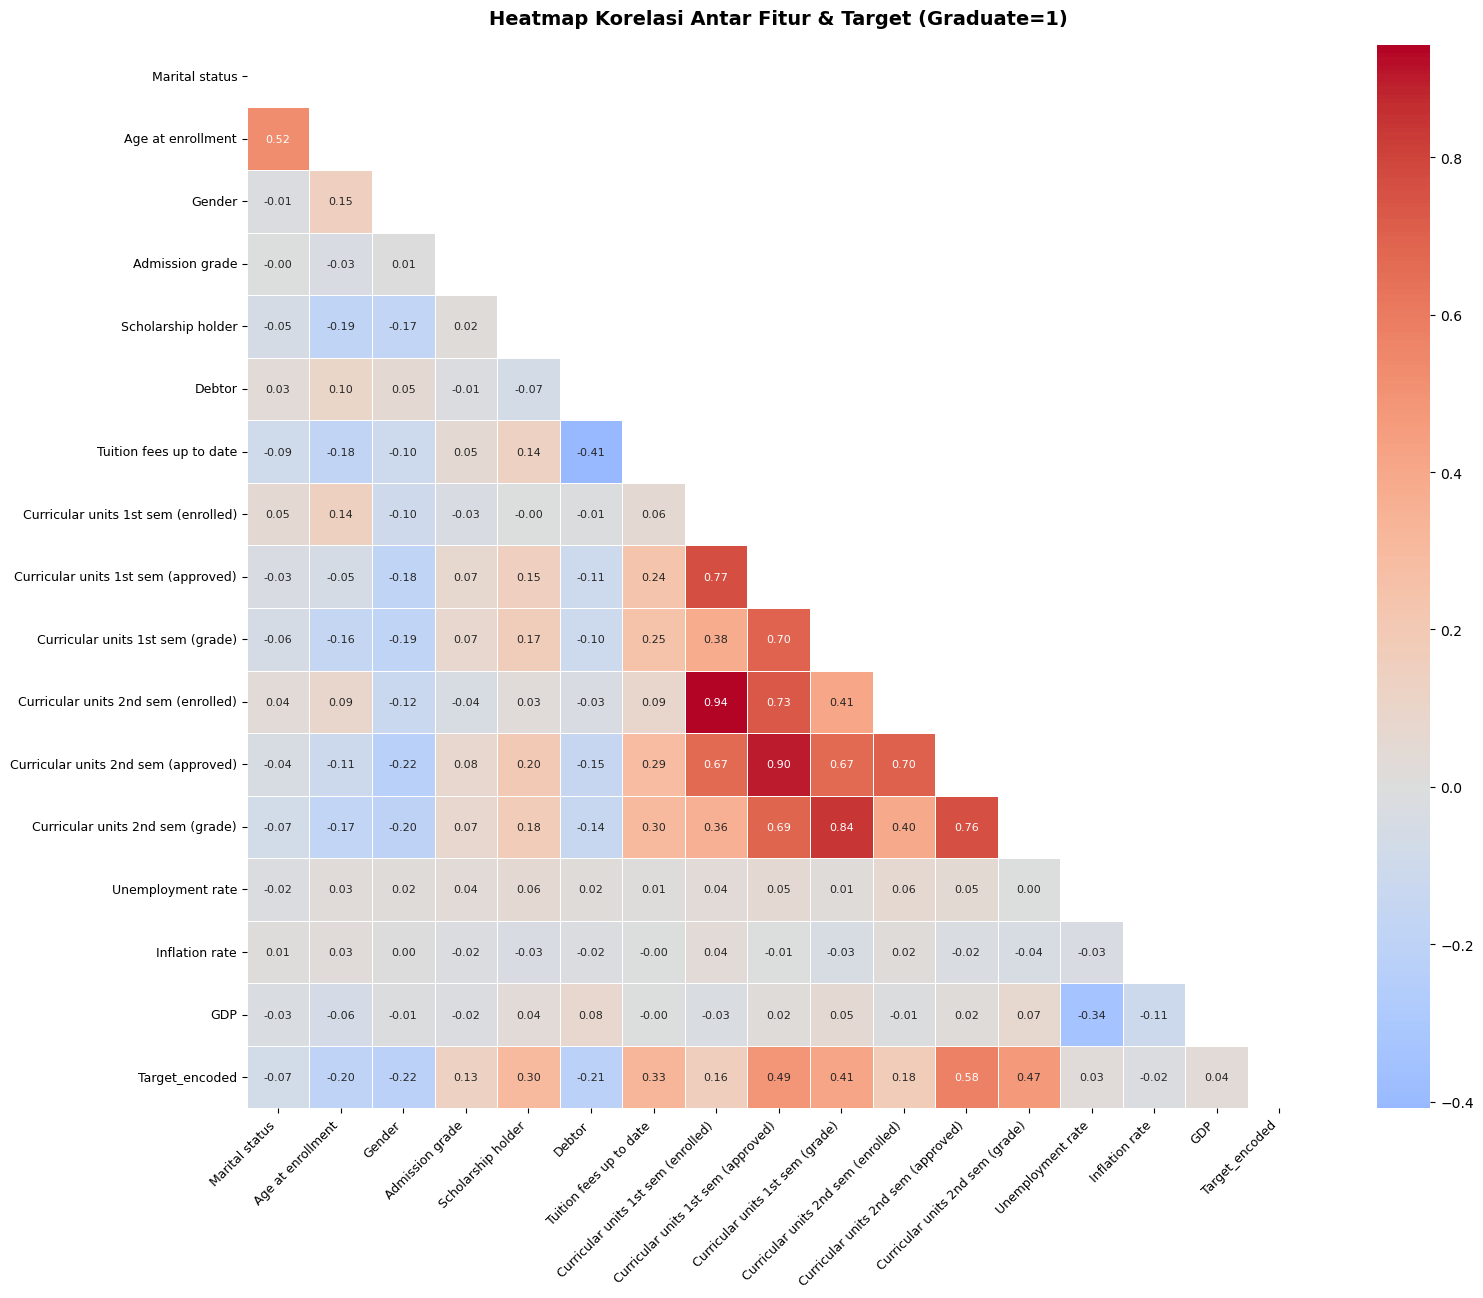

Top 5 fitur paling berkorelasi dengan kelulusan:
  + Curricular units 2nd sem (approved): 0.577
  + Curricular units 1st sem (approved): 0.492
  + Curricular units 2nd sem (grade): 0.473
  + Curricular units 1st sem (grade): 0.413
  + Tuition fees up to date: 0.327


In [8]:
# Heatmap Korelasi Fitur
# Buat salinan df dengan encoding target untuk korelasi numerik
df_corr = df.copy()
df_corr['Target_encoded'] = (df_corr['Target'] == 'Graduate').astype(int)

fitur_korelasi = [
    'Marital status', 'Age at enrollment', 'Gender',
    'Admission grade', 'Scholarship holder', 'Debtor',
    'Tuition fees up to date',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP',
    'Target_encoded'
]

corr_matrix = df_corr[fitur_korelasi].corr()

plt.figure(figsize=(16, 13))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask      = mask,
    annot     = True,
    fmt       = '.2f',
    cmap      = 'coolwarm',
    center    = 0,
    linewidths= 0.5,
    annot_kws = {'size': 8},
    square    = True
)
plt.title('Heatmap Korelasi Antar Fitur & Target (Graduate=1)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Tampilkan top korelasi dengan Target
top_corr = corr_matrix['Target_encoded'].drop('Target_encoded').abs().sort_values(ascending=False)
print('Top 5 fitur paling berkorelasi dengan kelulusan:')
for feat, val in top_corr.head(5).items():
    arah = '+' if corr_matrix['Target_encoded'][feat] > 0 else '-'
    print(f'  {arah} {feat}: {val:.3f}')

## Preprocessing

### Cek & Tangani Missing Value

In [9]:
# Cek kondisi awal
print('Missing value sebelum simulasi:', df.isnull().sum().sum())

Missing value sebelum simulasi: 0


In [10]:
# Inject missing value secara acak (simulasi kondisi data nyata)
np.random.seed(99)
kolom_inject = {
    'Admission grade'                  : 80,
    'Age at enrollment'                : 60,
    'Curricular units 1st sem (grade)' : 70,
    'Curricular units 2nd sem (grade)' : 65,
    'Unemployment rate'                : 50,
    'GDP'                              : 45,
}

for col, n in kolom_inject.items():
    idx = np.random.choice(df.index, size=n, replace=False)
    df.loc[idx, col] = np.nan

print('Missing value setelah simulasi:', df.isnull().sum().sum())
print()
df.isnull().sum()[df.isnull().sum() > 0]

Missing value setelah simulasi: 370



Admission grade                     80
Age at enrollment                   60
Curricular units 1st sem (grade)    70
Curricular units 2nd sem (grade)    65
Unemployment rate                   50
GDP                                 45
dtype: int64

In [11]:
# Imputasi dengan Median
for col in kolom_inject.keys():
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print('Missing value setelah imputasi:', df.isnull().sum().sum())
print()
df.isnull().sum()[df.isnull().sum() == 0]

Missing value setelah imputasi: 0



Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

### Penyederhanaan Label Target

In [12]:
# Target asli: Graduate, Dropout, Enrolled (3 kelas)
# Enrolled digabung ke Dropout → menjadi 2 kelas
print('Sebelum:')
print(df['Target'].value_counts())

df['Target'] = df['Target'].replace({'Enrolled': 'Dropout'})

print()
print('Sesudah (2 kelas):')
print(df['Target'].value_counts())

Sebelum:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Sesudah (2 kelas):
Target
Dropout     2215
Graduate    2209
Name: count, dtype: int64


### Pie Chart: Proporsi Graduate vs Dropout

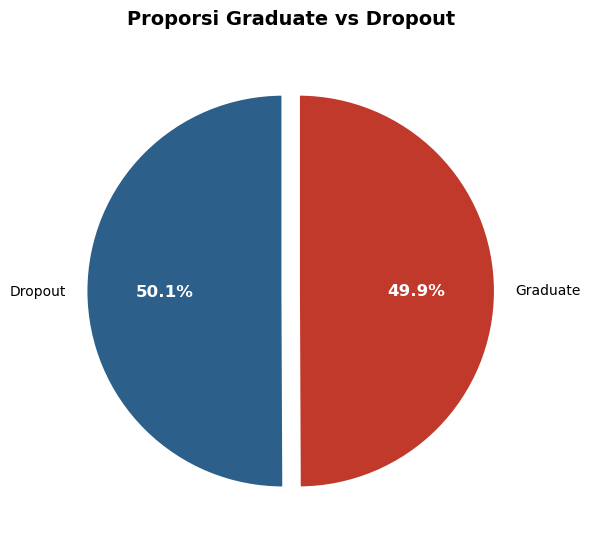

Jumlah per kelas:
  Dropout: 2215 (50.1%)
  Graduate: 2209 (49.9%)


In [13]:
# Pie Chart: Proporsi Graduate vs Dropout
target_counts = df['Target'].value_counts()

colors = ['#2C5F8A', '#C0392B']
explode = (0.04, 0.04)

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    target_counts,
    labels = target_counts.index,
    autopct = '%1.1f%%',
    colors = colors,
    explode = explode,
    startangle = 90,
    wedgeprops = dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

plt.title('Proporsi Graduate vs Dropout', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Jumlah per kelas:')
for label, count in target_counts.items():
    print(f'  {label}: {count} ({count/len(df)*100:.1f}%)')

### Deteksi Outlier (Metode IQR)

In [14]:
fitur_cek = [
    'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'GDP'
]

print('Deteksi Outlier (Metode IQR):\n')
for col in fitur_cek:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n   = ((df[col] < lb) | (df[col] > ub)).sum()
    print(f'  {col}: {n} outlier')

Deteksi Outlier (Metode IQR):

  Admission grade: 134 outlier
  Age at enrollment: 434 outlier
  Curricular units 1st sem (grade): 710 outlier
  Curricular units 2nd sem (grade): 863 outlier
  Unemployment rate: 0 outlier
  GDP: 0 outlier


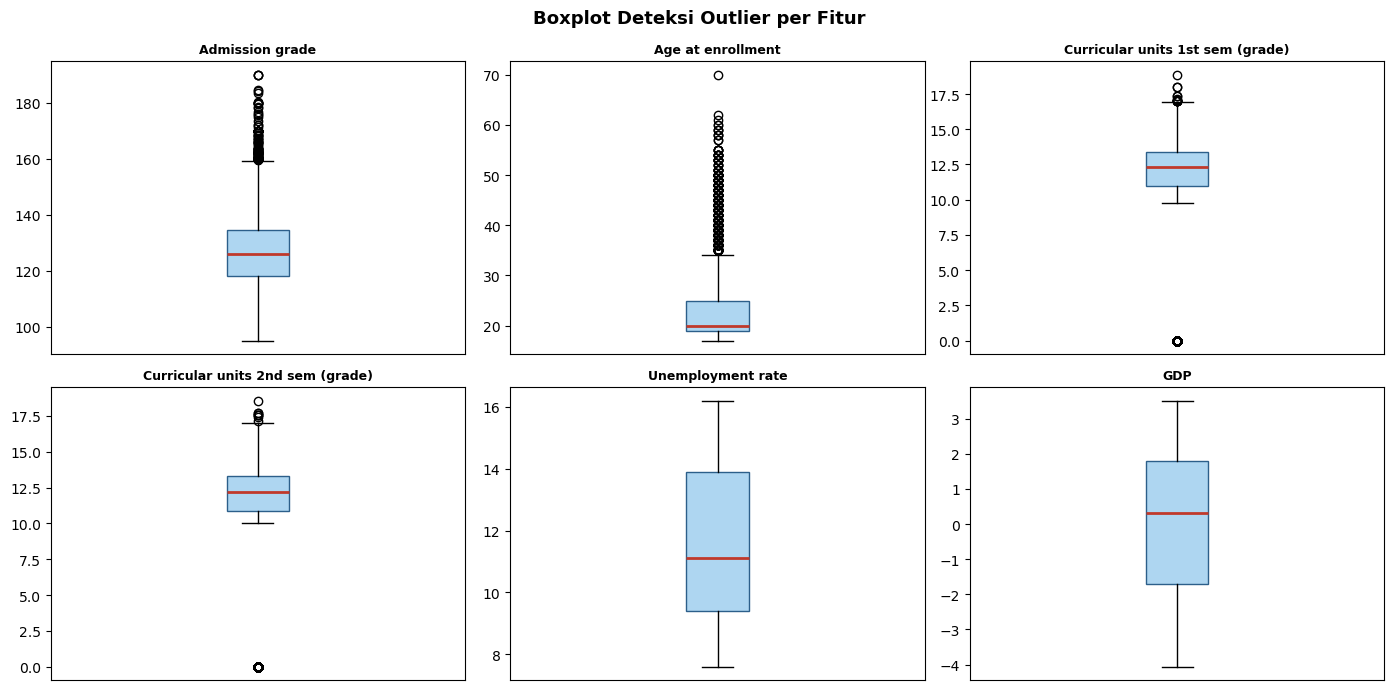

In [15]:
# Boxplot outlier
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(fitur_cek):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#2C5F8A'),
                    medianprops=dict(color='#C0392B', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])

fig.suptitle('Boxplot Deteksi Outlier per Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Seleksi Fitur & Label Encoding

In [16]:
# Drop kolom yang tidak dipakai, pisahkan fitur dan label
fitur = [
    'Marital status', 'Age at enrollment', 'Gender',
    'Admission grade', 'Scholarship holder', 'Debtor',
    'Tuition fees up to date',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

x = df[fitur]
y = df['CLASS'] if 'CLASS' in df.columns else df['Target']

In [17]:
# Label Encoding pada Target
print(y.unique())
le = LabelEncoder()
y  = le.fit_transform(y)

print('Hasil encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

['Dropout' 'Graduate']
Hasil encoding: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}


## Splitting Data

In [18]:
x_train, x_test, y_train, y_test = tts(x, y, test_size=0.3, random_state=0)

print('Data training :', x_train.shape[0], 'sampel')
print('Data testing  :', x_test.shape[0], 'sampel')

Data training : 3096 sampel
Data testing  : 1328 sampel


## Feature Scaling (StandardScaler)
SVM sensitif terhadap skala data, sehingga StandardScaler wajib dilakukan sebelum training.

In [19]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

## Modelling

In [20]:
model = SVC(random_state=0)
model.fit(x_train, y_train)

SVC(random_state=0)

In [21]:
predict = model.predict(x_test)
predict

array([1, 0, 1, ..., 1, 1, 1])

## Confusion Matrix

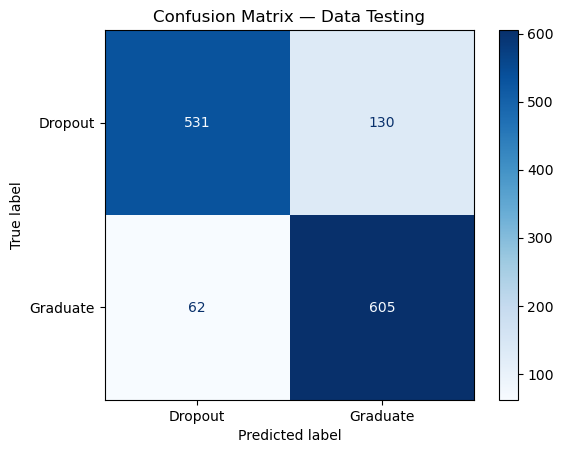

In [22]:
cm      = confusion_matrix(y_test, predict)
display = ConfusionMatrixDisplay(cm, display_labels=le.classes_)

display.plot(cmap='Blues')
plt.title('Confusion Matrix — Data Testing')
plt.show()

## Perbandingan Kernel SVM (linear vs rbf vs poly)

Melatih model dengan berbagai kernel...

  Kernel linear  : 84.34%
  Kernel rbf     : 85.54%
  Kernel poly    : 82.91%


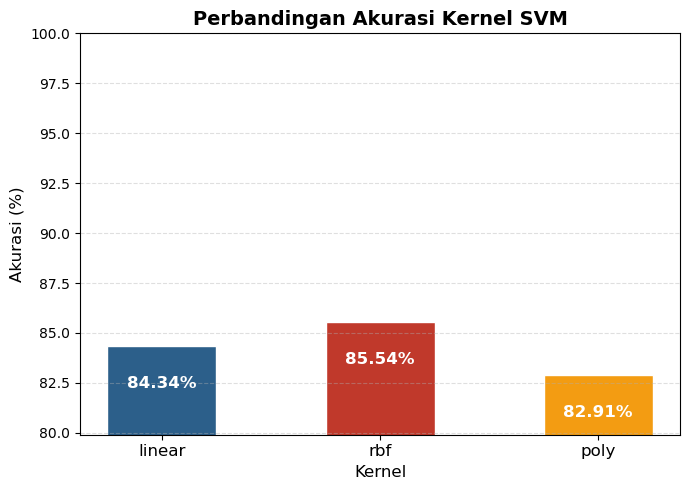


Kernel terbaik: rbf (85.54%)


In [23]:
# Perbandingan Akurasi Kernel: linear, rbf, poly
from sklearn.metrics import accuracy_score

kernels  = ['linear', 'rbf', 'poly']
acc_list = []

print('Melatih model dengan berbagai kernel...\n')
for k in kernels:
    m   = SVC(kernel=k, random_state=0)
    m.fit(x_train, y_train)
    acc = accuracy_score(y_test, m.predict(x_test)) * 100
    acc_list.append(acc)
    print(f'  Kernel {k:8s}: {acc:.2f}%')

# Bar chart
colors_bar = ['#2C5F8A', '#C0392B', '#F39C12']
plt.figure(figsize=(7, 5))
bars = plt.bar(kernels, acc_list, color=colors_bar, edgecolor='white', width=0.5)

for bar, acc in zip(bars, acc_list):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 1.5,
        f'{acc:.2f}%',
        ha='center', va='top',
        fontsize=12, fontweight='bold', color='white'
    )

plt.ylim(min(acc_list) - 3, 100)
plt.title('Perbandingan Akurasi Kernel SVM', fontsize=14, fontweight='bold')
plt.xlabel('Kernel', fontsize=12)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.xticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

best_kernel = kernels[acc_list.index(max(acc_list))]
print(f'\nKernel terbaik: {best_kernel} ({max(acc_list):.2f}%)')

## Evaluasi

In [24]:
print("SVM Accuracy Score: ", accuracy_score(y_test, predict) * 100, "%")

SVM Accuracy Score:  85.54216867469879 %


In [25]:
print(classification_report(y_test, predict, target_names=le.classes_))

              precision    recall  f1-score   support

     Dropout       0.90      0.80      0.85       661
    Graduate       0.82      0.91      0.86       667

    accuracy                           0.86      1328
   macro avg       0.86      0.86      0.85      1328
weighted avg       0.86      0.86      0.86      1328



Masukkan data mahasiswa secara manual untuk melihat prediksi status kelulusannya.

In [26]:
# Contoh data mahasiswa baru (urutan sesuai fitur yang dipakai)
# [Marital status, Age, Gender, Admission grade, Scholarship, Debtor,
#  Tuition up to date, CU1 enrolled, CU1 approved, CU1 grade,
#  CU2 enrolled, CU2 approved, CU2 grade, Unemployment, Inflation, GDP]

data_baru = pd.DataFrame([{
    'Marital status': 1,
    'Age at enrollment': 20,
    'Gender': 1,
    'Admission grade': 140.0,
    'Scholarship holder': 1,
    'Debtor': 0,
    'Tuition fees up to date': 1,
    'Curricular units 1st sem (enrolled)': 6,
    'Curricular units 1st sem (approved)': 6,
    'Curricular units 1st sem (grade)': 14.0,
    'Curricular units 2nd sem (enrolled)': 6,
    'Curricular units 2nd sem (approved)': 6,
    'Curricular units 2nd sem (grade)': 13.5,
    'Unemployment rate': 10.8,
    'Inflation rate': 1.4,
    'GDP': 1.74,
}])

data_baru_scaled = scaler.transform(data_baru)
hasil = model.predict(data_baru_scaled)
label_hasil = le.inverse_transform(hasil)

print('=== Hasil Prediksi ===')
print(f'Status Mahasiswa : {label_hasil[0]}')
print(f'Keterangan       : {"LULUS ✓" if label_hasil[0] == "Graduate" else "TIDAK LULUS / DROPOUT ✗"}')

=== Hasil Prediksi ===
Status Mahasiswa : Graduate
Keterangan       : LULUS ✓
